In [37]:
import os
from dotenv import load_dotenv
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, t as t_dist, f as f_dist
from scipy.stats._stats_py import LinregressResult
import comet_ml
from comet_ml.query import Parameter
from epiaudio.utils import nearest_value, get_ts_metrics

COMET_WORKSPACE = "epi-audio"
TOKEN_METRIC = "teacher_tokens"
KX_METRIC = "K(X)"
KM_METRIC = "K(M)"
EVAL_LOSS_METRIC = "teacher_eval_loss"
TRAIN_LOSS_METRIC = "train_loss"
EMA_LOSS_METRIC = "ema_teacher_eval_loss"
COMPUTE_METRIC = "compute"

load_dotenv()

COMET_API_KEY = os.environ["COMET_ML_API"]

# Recalculating Epiplexity with Eval Loss
Our training script calculates epiplexity as $K(M) = K(X, M) - K(X \mid M)$, where $K(X \mid M)$ is approximated by averaging the inter-eval training losses. Here we recalculate epiplexity by instead approximating $K(X \mid M)$ as average eval loss, weighted by the number of training tokens seen thus far.

In [38]:
def get_metadata_path(dataset_name, tokenizer_name):
    path = f"../../data/{dataset_name}_{tokenizer_name}/metadata.json"

    return path

def get_test_tokens(dataset_metadata_path):
    with open(dataset_metadata_path) as f:
        metadata = json.load(f)["test"]
    n_test_tokens = metadata["num_samples"]*metadata["tokens_per_sample"]

    return n_test_tokens

def query_experiments(sweep_name):
    api = comet_ml.API(api_key=COMET_API_KEY)
    query = Parameter("sweep_name") == sweep_name

    return api.query(COMET_WORKSPACE, "epiaudio", query)

In [39]:
def get_curve(experiment, n_test_tokens, idx):
    curve = []

    kx_by_ts = get_ts_metrics(experiment, KX_METRIC, scale=1e6)
    km_by_ts = get_ts_metrics(experiment, KM_METRIC, scale=1e6)
    loss_by_ts = get_ts_metrics(experiment, EVAL_LOSS_METRIC)
    ema_loss_records = experiment.get_metrics(EMA_LOSS_METRIC)
    compute_by_ts = get_ts_metrics(experiment, COMPUTE_METRIC)
    teacher_tokens_by_ts = get_ts_metrics(experiment, TOKEN_METRIC)

    for r in ema_loss_records:
        ts = r.get("timestamp")
        if ts is None:
            continue
        ts = int(ts)
        k_x = nearest_value(kx_by_ts, ts)
        old_k_m = nearest_value(km_by_ts, ts)
        avg_eval_loss = nearest_value(loss_by_ts, ts)
        compute = nearest_value(compute_by_ts, ts)
        teacher_tokens = nearest_value(teacher_tokens_by_ts, ts)
        if k_x is None or avg_eval_loss is None or compute is None or teacher_tokens is None:
            continue

        k_x_given_m = teacher_tokens*avg_eval_loss / np.log(2)
        k_m = k_x - k_x_given_m
        h_x = float(r["metricValue"]) * n_test_tokens / np.log(2)

        curve.append((compute, old_k_m, old_k_m + h_x, k_m, k_m + h_x, idx))

    return curve

def _lower_convex_hull(
    points: list[tuple[float, float, int, float]],
    tol: float = 0.0,
    reduce: str = "median",
    pos_only: bool = True
) -> list[tuple[float, float, int, float]]:
    if pos_only:
        points = [p for p in points if p[-1] > 0]
    if len(points) < 2:
        return sorted(points, key=lambda p: p[0])

    sorted_points = sorted(points, key=lambda p: p[0])

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    hull: list[tuple[float, float, int]] = []
    for point in sorted_points:
        while len(hull) >= 2 and cross(hull[-2], hull[-1], point) <= 0:
            hull.pop()
        if hull:
            min_y_so_far = min(p[1] for p in hull)
            if point[1] - min_y_so_far > tol * max(min_y_so_far, point[1]):
                continue
        hull.append(point)

    by_run: dict[int, list[tuple[float, float, int, float]]] = {}
    for p in hull:
        by_run.setdefault(p[2], []).append(p)

    reduced: list[tuple[float, float, int, float]] = []
    for run_points in by_run.values():
        xs = [p[0] for p in run_points]
        if reduce == "none":
            return sum(by_run.values(), [])
        elif reduce == "median":
            idx = int(np.argmin([abs(x - np.median(xs)) for x in xs]))
        elif reduce == "min":
            idx = int(np.argmin(xs))
        elif reduce == "max":
            idx = int(np.argmax(xs))
        else:
            raise ValueError(f"Unknown reduce method: {reduce!r}")
        reduced.append(run_points[idx])

    return sorted(reduced, key=lambda p: p[0])

In [40]:
def plot(ax, code_length_dim, epi_dim, points, hull, title):
    ax.scatter(
        [p[0] for p in points if p[epi_dim] > 0],
        [p[code_length_dim] for p in points if p[epi_dim] > 0],
        s=8,
        alpha=0.25,
        color="gray",
        label="eval steps (K(M) > 0)",
    )
    ax.scatter(
        [p[0] for p in points if p[epi_dim] <= 0],
        [p[code_length_dim] for p in points if p[epi_dim] <= 0],
        s=8,
        alpha=0.25,
        color="red",
        label="eval steps (K(M) <= 0)",
    )
    ax.plot(
        [p[0] for p in hull],
        [p[1] for p in hull],
        "o-",
        color="C0",
        label="Pareto front",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("compute (approx. 6ND)")
    ax.set_ylabel("K(M,X) (bits)")
    ax.legend()
    ax.set_title(title)

    return set(p[0] for p in points if p[epi_dim] <= 0)

def compare_plots(
    *,
    dataset_metadata_path,
    sweep_name
):
    old_experiments = query_experiments(sweep_name)
    all_points = []
    n_test_tokens = get_test_tokens(dataset_metadata_path)

    for idx, experiment in enumerate(old_experiments):
        api_experiment = comet_ml.APIExperiment(
            previous_experiment=experiment.key,
            api_key=COMET_API_KEY,
        )
        curve = get_curve(api_experiment, n_test_tokens, idx)
        all_points.extend(curve)

    old_hull = _lower_convex_hull(
        list((p[0], p[2], p[5], p[1]) for p in all_points),
        pos_only=False
    )
    hull = _lower_convex_hull(
        list((p[0], p[4], p[5], p[3]) for p in all_points),
        pos_only=False
    )
    old_hull_pos = _lower_convex_hull(list((p[0], p[2], p[5], p[1]) for p in all_points))
    hull_pos = _lower_convex_hull(list((p[0], p[4], p[5], p[3]) for p in all_points))

    print(f"Original epiplexity: {old_hull[-1][3]}")
    print(f"Recalculated epiplexity: {hull[-1][3]}")
    print(f"Original epiplexity (> 0 only): {old_hull_pos[-1][3]}")
    print(f"Recalculated epiplexity (> 0 only): {hull_pos[-1][3]}")


    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    plot(axs[0, 0], 2, 1, all_points, old_hull, "Original")
    plot(axs[0, 1], 4, 3, all_points, hull, "Recalculated")
    plot(axs[1, 0], 2, 1, all_points, old_hull_pos, "Original (> 0 only)")
    plot(axs[1, 1], 4, 3, all_points, hull_pos, "Recalculated (> 0 only)")
    fig.tight_layout()

    plt.show()

We make four code length vs. compute plots in a $2 \times 2$ grid. Plots in the left column use the from-script epiplexity calculation, while plots in the right column use our recalculation. In the top plots, we retain nonpositive model description length points, while in the bottom plots, we drop them. In all plots, points with nonpositive model description length are shown in red. The four epiplexity measurements are printed above the graphs.

Original epiplexity: -4567854.442352797
Recalculated epiplexity: 1705137.4305068962
Original epiplexity (> 0 only): 1391064.427170491
Recalculated epiplexity (> 0 only): 1705137.4305068962


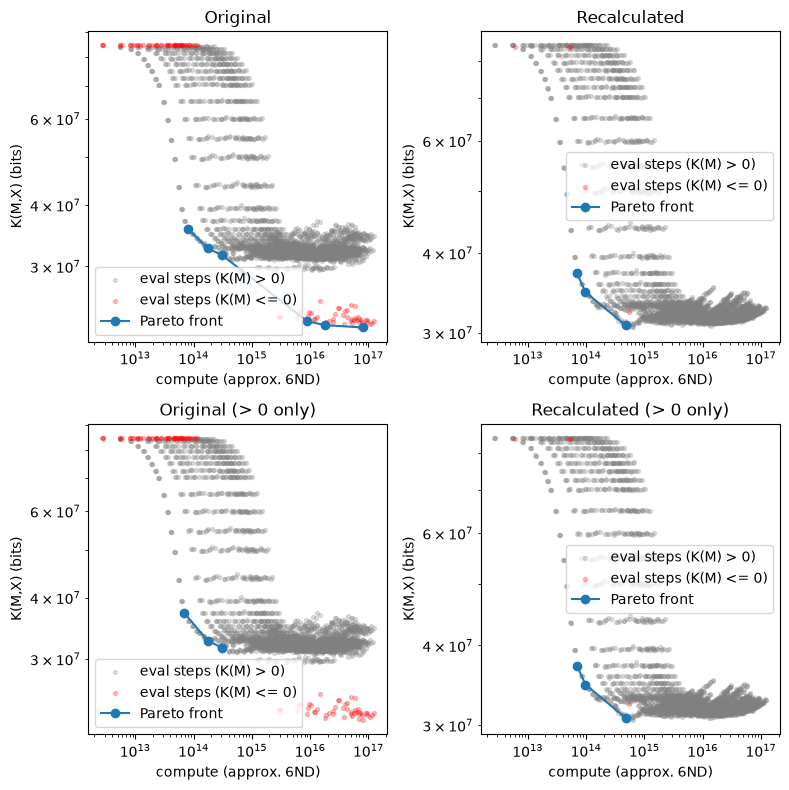

In [41]:
dataset_name = "toyadmos_toytrain"
tokenizer_name = "sqcodec"
sweep_name = "toyadmos_toytrain_epiplexity_sqcodec__2026-08-11_05:01:39"
compare_plots(
    dataset_metadata_path=get_metadata_path(dataset_name, tokenizer_name),
    sweep_name=sweep_name
)

---
# Recalculate Epiplexity by Smoothing Training Loss

Here we recalculate epiplexity in another way: we use linear regression to obtain a smooth approximation to our loss function. We then calculate epiplexity using the area of the smoothed loss vs. training tokens curve.

In [42]:
def _model_bits_from_loss_curve(loss_curve) -> list[float]:
    loss_curve = sorted(loss_curve, key=lambda p: p[0])
    tokens, losses = zip(*loss_curve)
    n_points = len(tokens)
    model_bits = []
    for n in range(1, n_points):
        area_under_curve = np.trapezoid(losses[:n + 1], x=tokens[:n + 1]) 
        area_under_final_loss = (tokens[n] - tokens[0])*losses[n]
        bits = (area_under_curve - area_under_final_loss) / np.log(2)
        model_bits.append(bits)

    return model_bits

def _smooth_loss_curve(loss_curve) -> tuple[LinregressResult, list[tuple[float, float]]]:
    loss_curve = sorted(loss_curve, key=lambda p: p[0])
    shift = min(np.log(p[0]) for p in loss_curve) - 1
    tokens = np.array([np.log(np.log(p[0]) - shift) for p in loss_curve])
    losses = np.array([np.log(p[1]) for p in loss_curve])

    fit = linregress(tokens, losses)
    def smooth_loss(tokens):
        x = np.log(np.log(tokens) - shift)
        return np.exp(fit.intercept + fit.slope * x)

    return fit, [(tokens, smooth_loss(tokens)) for tokens, _ in loss_curve]

def _smooth_run_points(
    experiment,
    idx,
    test_tokens
) -> tuple[list[tuple[float, float]], list[tuple[float, float, int, float]]]:
    train_tokens_records = get_ts_metrics(experiment, TOKEN_METRIC)
    compute_records = get_ts_metrics(experiment, COMPUTE_METRIC)
    raw_loss_records = get_ts_metrics(experiment, TRAIN_LOSS_METRIC)
    ema_loss_records = experiment.get_metrics(EMA_LOSS_METRIC)

    loss_curve = []
    entropy_curve = []
    for r in ema_loss_records:
        ts = r.get("timestamp")
        if ts is None:
            continue
        ts = int(ts)
        train_tokens = nearest_value(train_tokens_records, ts)
        compute = nearest_value(compute_records, ts)
        raw_loss = nearest_value(raw_loss_records, ts)
        ema_loss = float(r["metricValue"])
        if any(val is None for val in (compute, raw_loss, ema_loss)):
            continue
        entropy_bits = ema_loss * test_tokens / np.log(2)
        entropy_curve.append((compute, entropy_bits))
        loss_curve.append((train_tokens, raw_loss))

    _, smoothed_loss_curve = _smooth_loss_curve(loss_curve)
    model_bit_counts = _model_bits_from_loss_curve(smoothed_loss_curve)

    return loss_curve, [
        (
            compute,
            model_bits + entropy_bits,
            idx,
            model_bits
        )
        for (compute, entropy_bits), model_bits in zip(entropy_curve[1:], model_bit_counts)
    ]


def get_smooth_code_points(
    sweep_name: str,
    test_tokens: int
) -> list[tuple[float, float, int, float]]:
    experiments = query_experiments(sweep_name)

    all_points = []
    for run_idx, experiment in enumerate(experiments):
        api_experiment = comet_ml.APIExperiment(
            previous_experiment=experiment.key,
            api_key=COMET_API_KEY,
        )
        _, code_points = _smooth_run_points(api_experiment, run_idx, test_tokens)
        all_points.extend(code_points)

    return all_points

Here we perform the smoothing on an example loss curve using a run from an old sweep. We plot the actual (grey) and smoothed (blue) training losses, and print out the statistics from the linear regression.

If $b_0,b_1$ are the intercept and slope from our linear regression model, respectively, then our smoothed loss is a function $\ell$ of the number of training tokens $t$, given by
$$\ell(t) = e^{b_0 + b_1\log (\log(t - t_{\min} + 1))},$$
where $t_{\min}$ is the smallest number of training tokens among all data points.

R^2: 0.7208437494259509
Correlation coefficient: -0.8490251759670916
RMSE: 0.8080979471512283
Slope: -12.343061588809833, SE=0.032349692287019415, t=-12.343061588809833, p=5.439188666087039e-18
Intercept: 38.074337550347025, SE=0.055437145772105165, t=38.074337550347025, p=3.124474201100546e-43
F-statistic: F(1, 59)=152.35116938515276, p=5.4391886660869434e-18


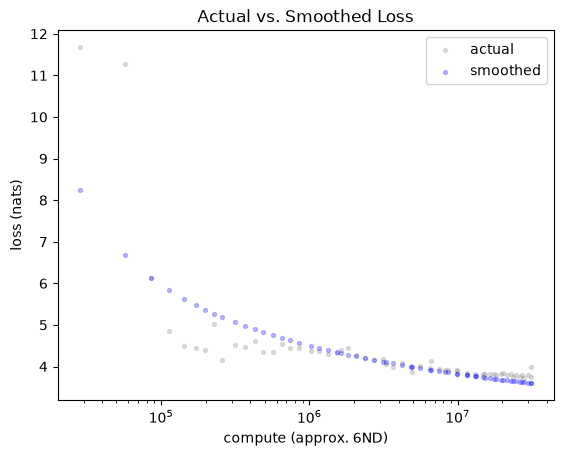

In [43]:
dataset_name = "toyadmos_toytrain"
tokenizer_name = "sqcodec"
sweep_name = "toyadmos_toytrain_epiplexity_sqcodec__2026-08-11_05:01:39"
dataset_metadata_path = get_metadata_path(dataset_name, tokenizer_name)

test_tokens = get_test_tokens(dataset_metadata_path)
experiments = query_experiments(sweep_name)
idx = 0
experiment = comet_ml.APIExperiment(
    previous_experiment=experiments[idx].key,
    api_key=COMET_API_KEY,
)

loss_curve, _ = _smooth_run_points(experiment, idx, test_tokens)
linregress_result, smooth_loss_curve = _smooth_loss_curve(loss_curve)

actual_losses = np.array([p[1] for p in sorted(loss_curve, key=lambda p: p[0])])
predicted_losses = np.array([p[1] for p in smooth_loss_curve])
rmse = np.sqrt(np.mean((actual_losses - predicted_losses)**2))

df = len(smooth_loss_curve) - 2
slope_t = linregress_result.slope / linregress_result.stderr
intercept_t = linregress_result.intercept / linregress_result.intercept_stderr
intercept_pvalue = 2 * t_dist.sf(np.abs(intercept_t), df)

r_squared = linregress_result.rvalue**2
f_stat = (r_squared / 1) / ((1 - r_squared) / df)
f_pvalue = f_dist.sf(f_stat, 1, df)



print(f"R^2: {r_squared}")
print(f"Correlation coefficient: {linregress_result.rvalue}")
print(f"RMSE: {rmse}")
print(f"Slope: {slope_t}, SE={linregress_result.stderr}, t={slope_t}, p={linregress_result.pvalue}")
print(f"Intercept: {intercept_t}, SE={linregress_result.intercept_stderr}, t={intercept_t}, p={intercept_pvalue}")
print(f"F-statistic: F(1, {df})={f_stat}, p={f_pvalue}")

plt.scatter(
    [p[0] for p in loss_curve],
    [p[1] for p in loss_curve],
    s=8,
    alpha=0.25,
    color="gray",
    label="actual",
)
plt.scatter(
    [p[0] for p in smooth_loss_curve],
    [p[1] for p in smooth_loss_curve],
    s=8,
    alpha=0.25,
    color="blue",
    label="smoothed",
)
plt.xscale("log")
plt.xlabel("compute (approx. 6ND)")
plt.ylabel("loss (nats)")
plt.legend() 
plt.title("Actual vs. Smoothed Loss")
plt.show()

In [44]:
def make_plot_grid(
    *,
    dataset_metadata_path,
    sweep_name
):
    old_experiments = query_experiments(sweep_name)
    all_points = []
    n_test_tokens = get_test_tokens(dataset_metadata_path)

    for idx, experiment in enumerate(old_experiments):
        api_experiment = comet_ml.APIExperiment(
            previous_experiment=experiment.key,
            api_key=COMET_API_KEY,
        )
        curve = get_curve(api_experiment, n_test_tokens, idx)
        all_points.extend(curve)

    old_hull = _lower_convex_hull(
        list((p[0], p[2], p[5], p[1]) for p in all_points),
        pos_only=False
    )
    old_hull_pos = _lower_convex_hull(list((p[0], p[2], p[5], p[1]) for p in all_points))

    smooth_points = get_smooth_code_points(sweep_name, n_test_tokens)
    hull = _lower_convex_hull(smooth_points)
    hull_pos = _lower_convex_hull(list(p for p in smooth_points if p[3] > 0))
    

    print(f"Original epiplexity: {old_hull[-1][3]}")
    print(f"Smoothed training loss epiplexity: {hull[-1][3]}")
    print(f"Original epiplexity (> 0 only): {old_hull_pos[-1][3]}")
    print(f"Smoothed training loss (> 0 only): {hull_pos[-1][3]}")


    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    plot(axs[0, 0], 2, 1, all_points, old_hull, "Original")
    plot(axs[0, 1], 1, 3, smooth_points, hull, "Smoothed Training Loss")
    plot(axs[1, 0], 2, 1, all_points, old_hull_pos, "Original (> 0 only)")
    plot(axs[1, 1], 1, 3, smooth_points, hull_pos, "Smoothed Training Loss (> 0 only)")
    fig.tight_layout()

    plt.show()

Again, we show code length vs. compute plots for the from-script calculation and for our calculation based on smoothed training loss. The plots in the left column use the from-script calculation, while the plots in the right column use smoothed training loss. In the top plots, we retain nonpositive model description length points, while in the bottom plots, we drop them. In all plots, points with nonpositive model description length are shown in red. The four epiplexity measurements are printed above the graphs.

Original epiplexity: -4567854.442352797
Smoothed training loss epiplexity: 2166392.5871495325
Original epiplexity (> 0 only): 1391064.427170491
Smoothed training loss (> 0 only): 2166392.5871495325


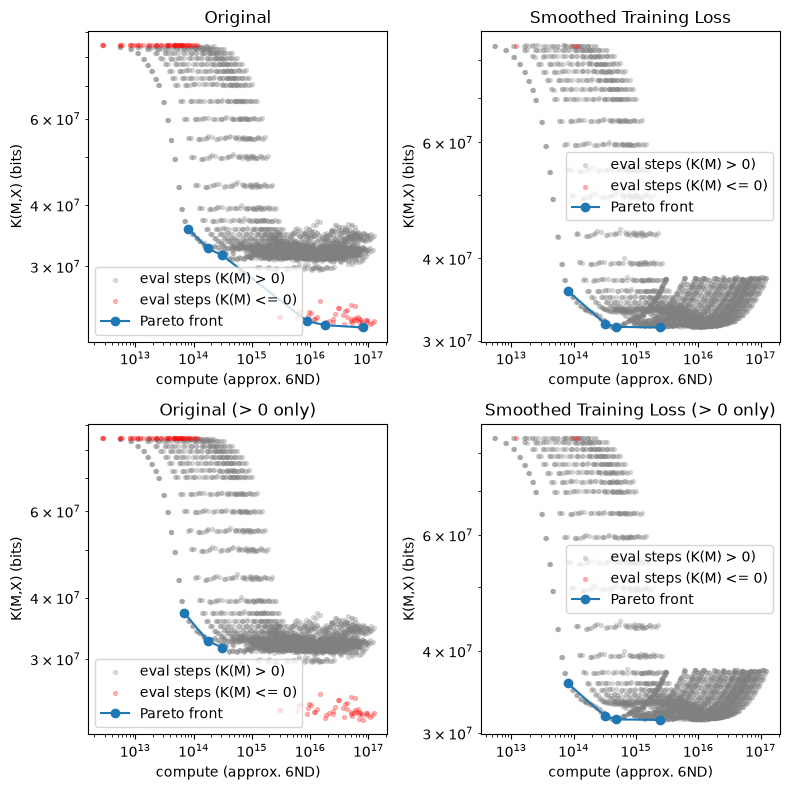

In [45]:
dataset_name = "toyadmos_toytrain"
tokenizer_name = "sqcodec"
sweep_name = "toyadmos_toytrain_epiplexity_sqcodec__2026-08-11_05:01:39"
make_plot_grid(
    dataset_metadata_path=get_metadata_path(dataset_name, tokenizer_name),
    sweep_name=sweep_name
)